# SHAP Analysis for Tuned XGBoost

SHAP (SHapley Additive exPlanations) is used to explain the predictions of the tuned XGBoost model. SHAP assigns an importance value to each feature based on its contribution to the model's predictions.

The objectives of this analysis are:

- Identify the most important features influencing Higgs Boson classification.
- Understand how feature values affect model predictions.
- Select the most relevant features for Quantum Machine Learning models.
- Improve model interpretability and transparency.

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import joblib
import shap

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

c:\Users\nabia\ALL_PROJECTS\ML_Project\venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# Load Tuned XGBoost Model
# ============================================================

xgb = joblib.load(
    "../models/higgs_xgboost_tuned.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


In [3]:
# ============================================================
# Load Dataset
# ============================================================

from preprocessing_22 import load_data_unscaled

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
    feature_names
) = load_data_unscaled()

print(X_test.shape)
print(X_train.shape)

(122736, 30)
(572766, 30)


In [4]:
# ============================================================
# Create SHAP Explainer
# ============================================================

explainer = shap.TreeExplainer(
    xgb
)

print("SHAP Explainer Created")

SHAP Explainer Created


In [5]:
# ============================================================
# Compute SHAP Values
# ============================================================

X_sample = X_test.sample(
    n=5000,
    random_state=42
)

shap_values = explainer.shap_values(
    X_sample
)

print("SHAP values computed.")

SHAP values computed.


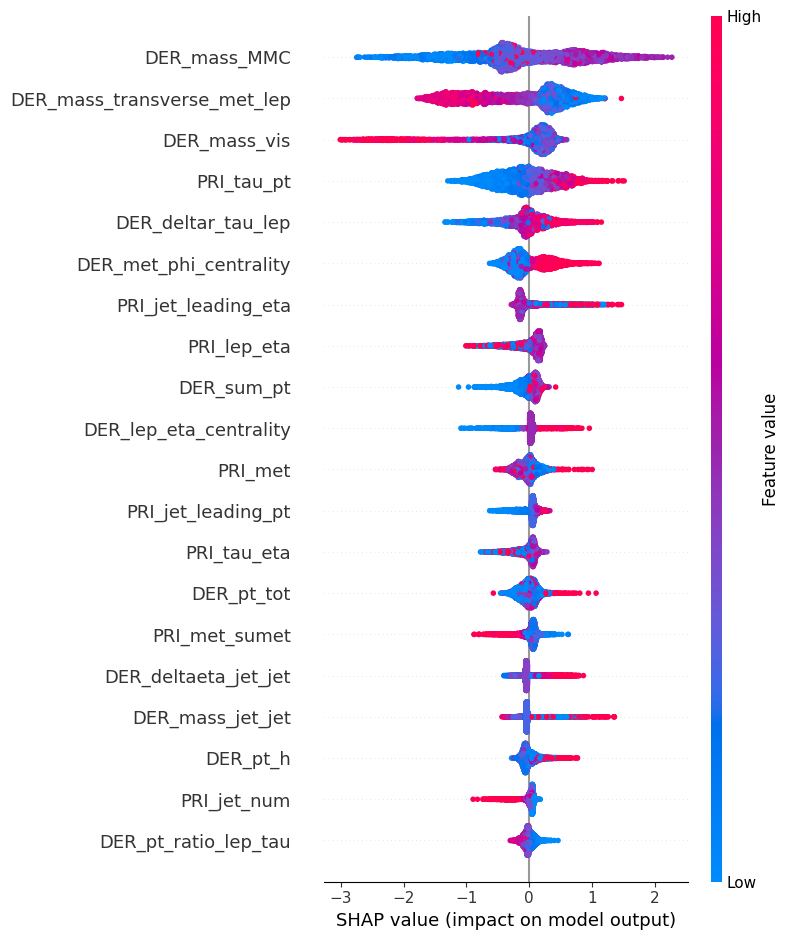

In [6]:
# ============================================================
# SHAP Summary Plot
# ============================================================

shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../results/explainability/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

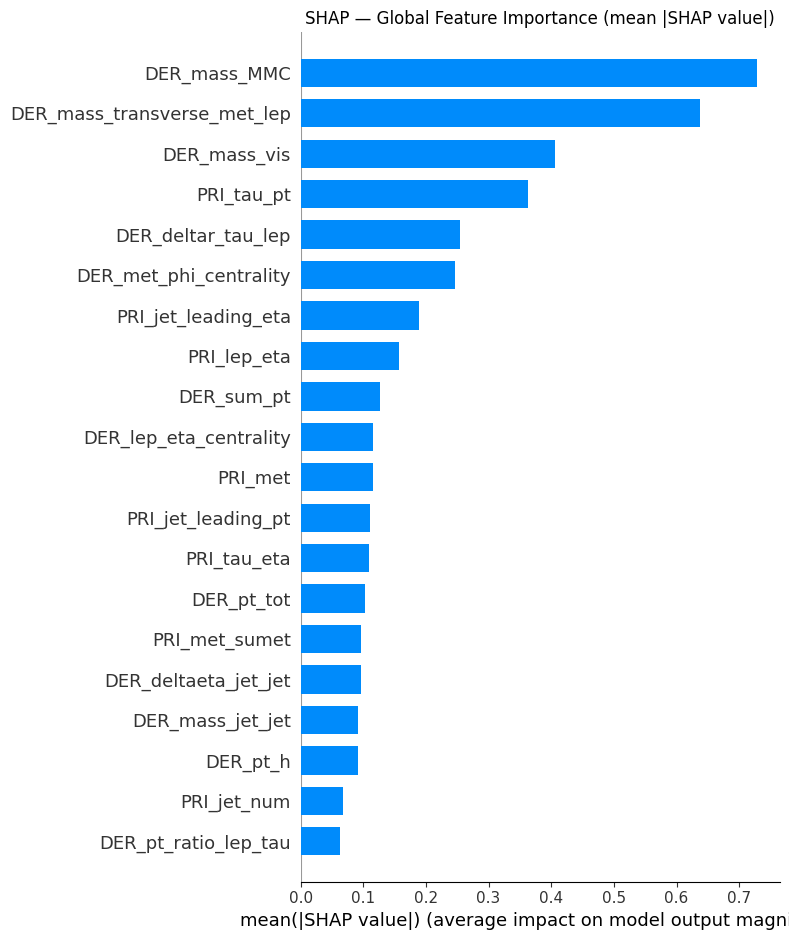

In [7]:
# ============================================================
# SHAP Feature Importance
# ============================================================

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=False
)
plt.title("SHAP — Global Feature Importance (mean |SHAP value|)")
plt.tight_layout()

plt.savefig(
    "../results/explainability/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
# ============================================================
# Create SHAP Importance Table
# ============================================================

shap_importance = pd.DataFrame({
    "Feature": X_sample.columns,
    "Importance":
    np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Importance",
    ascending=False
)

shap_importance.head(20)

,Feature,Importance
0,DER_mass_MMC,0.728814
1,DER_mass_transverse_met_lep,0.637328
2,DER_mass_vis,0.405446
13,PRI_tau_pt,0.362965
7,DER_deltar_tau_lep,0.253615
11,DER_met_phi_centrality,0.247108
24,PRI_jet_leading_eta,0.188593
17,PRI_lep_eta,0.157000
9,DER_sum_pt,0.126949
12,DER_lep_eta_centrality,0.115442


In [9]:
# ============================================================
# Save SHAP Importance
# ============================================================

shap_importance.to_csv(
    "../results/tables/shap_feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [10]:
# ============================================================
# Top 10 Features
# ============================================================

top10_features = (
    shap_importance
    .head(10)["Feature"]
    .tolist()
)

print(top10_features)

['DER_mass_MMC', 'DER_mass_transverse_met_lep', 'DER_mass_vis', 'PRI_tau_pt', 'DER_deltar_tau_lep', 'DER_met_phi_centrality', 'PRI_jet_leading_eta', 'PRI_lep_eta', 'DER_sum_pt', 'DER_lep_eta_centrality']


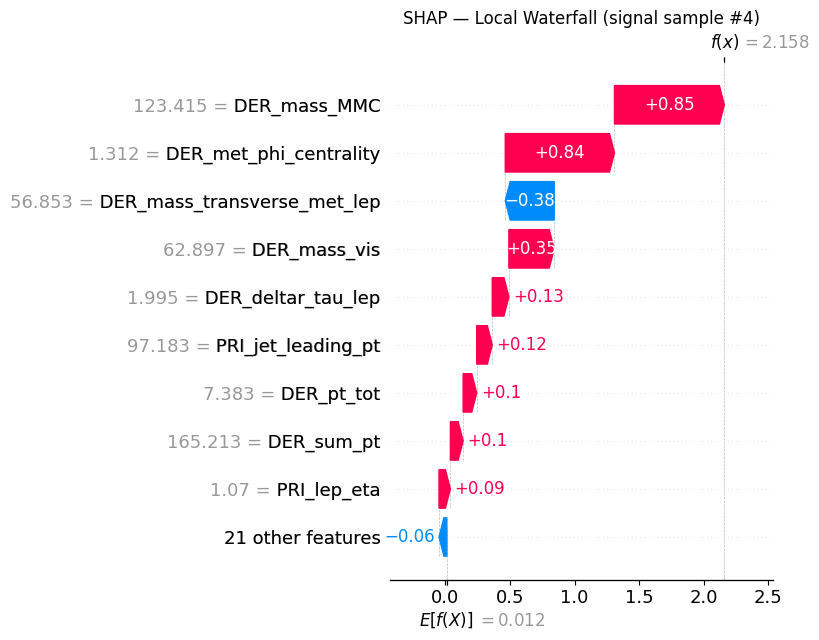

Saved: shap_waterfall_signal.png


In [11]:
# ── A4. Local — Waterfall for one signal sample ──────────────
signal_idx     = int(np.where(xgb.predict(X_sample) == 1)[0][0])
background_idx = int(np.where(xgb.predict(X_sample) == 0)[0][0])

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[signal_idx],
        base_values   = explainer.expected_value,
        data          = X_sample.iloc[signal_idx].values,
        feature_names = feature_names
    ),
    show=False
)
plt.title(f"SHAP — Local Waterfall (signal sample #{signal_idx})")
plt.tight_layout()
#plt.savefig("../results/explainability/shap_waterfall_signal.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: shap_waterfall_signal.png")

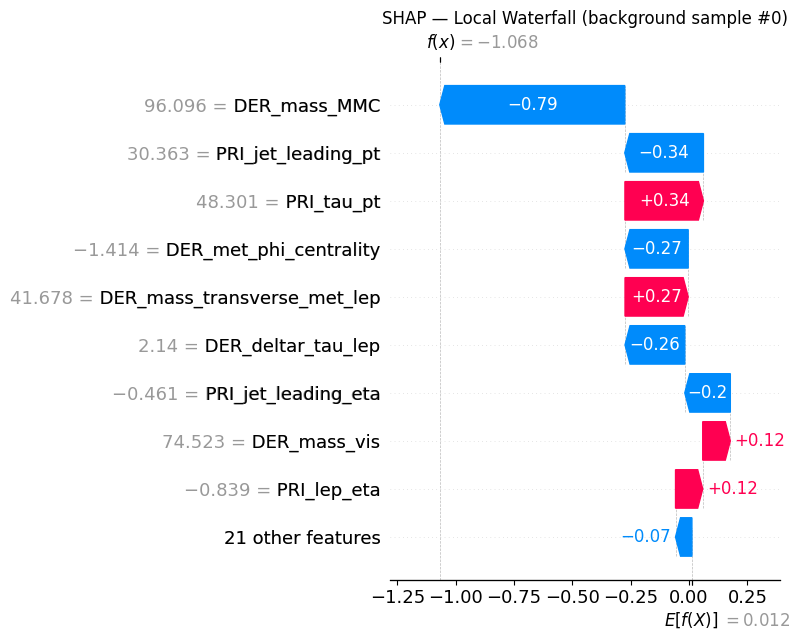

In [12]:
#Local — Waterfall for one background sample 
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[background_idx],
        base_values   = explainer.expected_value,
        data          = X_sample.iloc[background_idx].values,
        feature_names = feature_names
    ),
    show=False
)
plt.title(f"SHAP — Local Waterfall (background sample #{background_idx})")
plt.tight_layout()
#plt.savefig("../results/explainability/shap_waterfall_background.png", dpi=150, bbox_inches="tight")
plt.show()
#print(f"Saved: shap_waterfall_background.png")

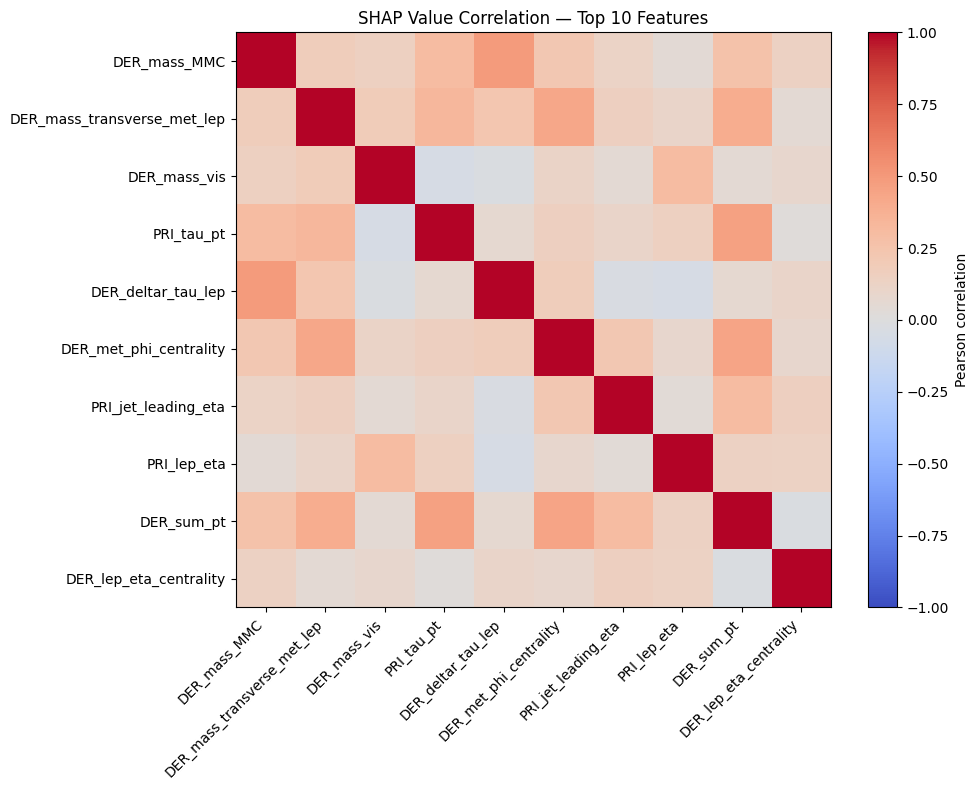

Saved: shap_correlation_heatmap.png


In [13]:
# ── A3. Global — SHAP correlation heatmap (top 10) ──────────
top10_idx   = np.argsort(np.abs(shap_values).mean(axis=0))[::-1][:10]
top10_names = [feature_names[i] for i in top10_idx]

shap_df = pd.DataFrame(shap_values[:, top10_idx], columns=top10_names)
plt.figure(figsize=(10, 8))
plt.imshow(shap_df.corr(), cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(top10_names)), top10_names, rotation=45, ha="right")
plt.yticks(range(len(top10_names)), top10_names)
plt.title("SHAP Value Correlation — Top 10 Features")
plt.tight_layout()
plt.savefig("../results/explainability/shap_correlation_heatmap.png", dpi=150)
plt.show()
print("Saved: shap_correlation_heatmap.png")

<Figure size 640x480 with 0 Axes>

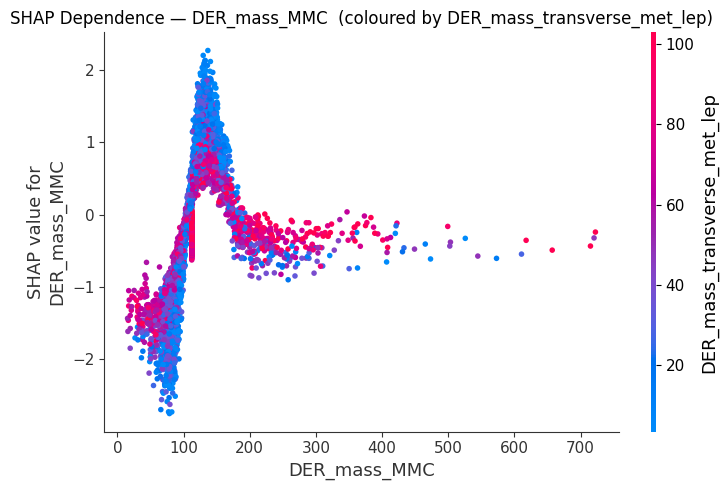

Saved: shap_dependence.png


In [14]:
top1 = top10_names[0]
top2 = top10_names[1]

plt.figure()
shap.dependence_plot(
    top1,
    shap_values,
    X_sample,
    interaction_index=top2,
    feature_names=feature_names,
    show=False
)
plt.title(f"SHAP Dependence — {top1}  (coloured by {top2})")
plt.tight_layout()
plt.savefig("../results/explainability/shap_dependence.png", dpi=150)
plt.show()
print(f"Saved: shap_dependence.png")